In [1]:
# ==========================================================
# Gemstone Detection using Transfer Learning
# ----------------------------------------------------------
# This notebook trains a deep learning model to classify
# images into two categories:
#
#     1. Gemstone
#     2. NotGem
#
# The model is built using TensorFlow and EfficientNetB0
# with Transfer Learning.
#
# Author : Sithumini
# ==========================================================

# ==========================================================
# Import Required Libraries
# ==========================================================
#
# TensorFlow
#     Deep learning framework used to build and train
#     the convolutional neural network.
#
# NumPy
#     Performs numerical operations and array manipulation.
#
# Matplotlib
#     Used to visualize images and training results.
#
# Random
#     Ensures reproducibility by fixing random seeds.
#
# Path
#     Provides platform-independent file path handling.
# ==========================================================

import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("=" * 60)
print("TensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)
print("=" * 60)

TensorFlow Version : 2.21.0
NumPy Version      : 2.2.6


In [2]:
# ==========================================================
# Set Random Seeds
# ==========================================================
#
# Machine learning experiments involve random operations,
# such as:
#
# • Weight initialization
# • Data shuffling
# • Data augmentation
#
# Setting fixed random seeds makes the experiment more
# reproducible. Running the notebook multiple times is
# more likely to produce consistent results.
# ==========================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

tf.random.set_seed(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


In [3]:
# ==========================================================
# Dataset Configuration
# ==========================================================
#
# Define the location of the processed dataset and the
# model training parameters.
#
# IMAGE_SIZE
#     All images are resized to 224 × 224 pixels because
#     EfficientNetB0 expects this input size.
#
# BATCH_SIZE
#     Number of images processed in a single training step.
#
# AUTOTUNE
#     Allows TensorFlow to automatically optimize the data
#     pipeline for improved performance.
# ==========================================================

DATASET_PATH = Path("../datasets/processed")

TRAIN_PATH = DATASET_PATH / "train"
VALIDATION_PATH = DATASET_PATH / "validation"
TEST_PATH = DATASET_PATH / "test"

IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE

print("Dataset configuration completed.")

Dataset configuration completed.


In [4]:
# ==========================================================
# Load Image Datasets
# ==========================================================
#
# TensorFlow automatically loads images from the directory
# structure.
#
# Expected folder structure:
#
# datasets/
# └── processed/
#     ├── train/
#     │   ├── Gemstone/
#     │   └── NotGem/
#     │
#     ├── validation/
#     │   ├── Gemstone/
#     │   └── NotGem/
#     │
#     └── test/
#         ├── Gemstone/
#         └── NotGem/
#
# label_mode="binary"
#     Since this is a binary classification problem,
#     TensorFlow assigns:
#
#         Gemstone -> 0
#         NotGem   -> 1
#
# Images are resized to 224 × 224 pixels during loading.
# ==========================================================

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

# Store class names before dataset optimization.
class_names = train_dataset.class_names

print("\nClass Labels:")
print(class_names)

Found 7034 files belonging to 2 classes.
Found 879 files belonging to 2 classes.
Found 880 files belonging to 2 classes.

Class Labels:
['Gemstone', 'NotGem']


In [5]:
# ==========================================================
# Display Dataset Statistics
# ==========================================================
#
# This section verifies that the datasets have been loaded
# correctly before training.
#
# We display:
#
# • Class labels
# • Number of batches
# • Approximate number of images
#
# Verifying the dataset at this stage helps identify
# problems before training begins.
# ==========================================================

print("=" * 50)

print("Class Labels")
print(class_names)

print("=" * 50)

print(f"Training Batches   : {len(train_dataset)}")
print(f"Validation Batches : {len(validation_dataset)}")
print(f"Test Batches       : {len(test_dataset)}")

print("=" * 50)

print(f"Training Images   ≈ {len(train_dataset) * BATCH_SIZE}")
print(f"Validation Images ≈ {len(validation_dataset) * BATCH_SIZE}")
print(f"Test Images       ≈ {len(test_dataset) * BATCH_SIZE}")

print("=" * 50)

Class Labels
['Gemstone', 'NotGem']
Training Batches   : 220
Validation Batches : 28
Test Batches       : 28
Training Images   ≈ 7040
Validation Images ≈ 896
Test Images       ≈ 896


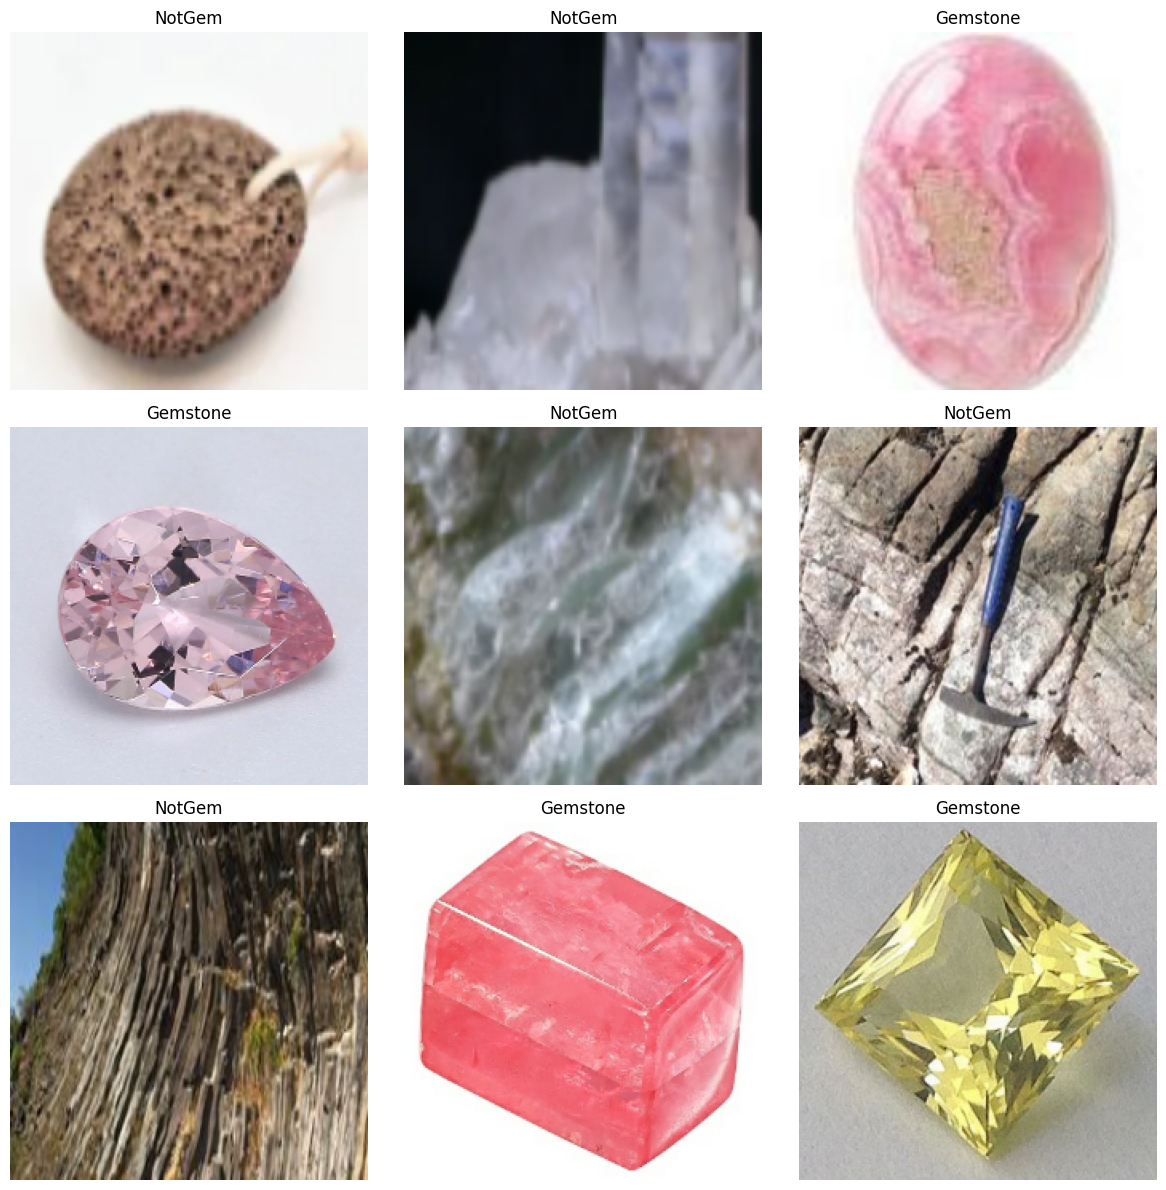

In [6]:
# ==========================================================
# Visualize Sample Images
# ==========================================================
#
# Before training, it is important to inspect the dataset.
#
# This step confirms:
#
# • Images are loaded correctly.
# • Labels are assigned correctly.
# • Images have been resized properly.
# • No corrupted images exist.
#
# This is considered a standard sanity check in deep
# learning workflows.
# ==========================================================

plt.figure(figsize=(12, 12))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[int(labels[i].numpy()[0])])

        plt.axis("off")

plt.tight_layout()

plt.show()

In [7]:
# ==========================================================
# Optimize the TensorFlow Data Pipeline
# ==========================================================
#
# The tf.data API provides several optimizations that
# improve training performance.
#
# cache()
#     Stores images in memory after the first epoch,
#     reducing disk access.
#
# prefetch()
#     Loads the next batch while the current batch is
#     being processed, reducing GPU/CPU idle time.
#
# These optimizations improve training speed without
# changing the dataset itself.
# ==========================================================

train_dataset = (
    train_dataset
    .cache()
    .prefetch(AUTOTUNE)
)

validation_dataset = (
    validation_dataset
    .cache()
    .prefetch(AUTOTUNE)
)

test_dataset = (
    test_dataset
    .cache()
    .prefetch(AUTOTUNE)
)

print("Dataset optimization completed successfully.")

Dataset optimization completed successfully.


In [8]:
# ==========================================================
# Data Augmentation
# ==========================================================
#
# Data augmentation artificially increases the diversity
# of the training dataset by applying random image
# transformations during training.
#
# Instead of collecting thousands of additional gemstone
# images, TensorFlow generates slightly different versions
# of existing images on the fly.
#
# Benefits:
#
# • Reduces overfitting.
# • Improves model generalization.
# • Makes the model more robust to variations in
#   orientation, lighting, and scale.
#
# Note:
# Data augmentation is applied ONLY to the training
# dataset. Validation and test datasets remain unchanged.
# ==========================================================

data_augmentation = tf.keras.Sequential([

    # Randomly flip images horizontally.
    tf.keras.layers.RandomFlip("horizontal"),

    # Rotate images by up to ±10%.
    tf.keras.layers.RandomRotation(0.10),

    # Randomly zoom into the image by up to 10%.
    tf.keras.layers.RandomZoom(0.10),

    # Randomly adjust image contrast.
    tf.keras.layers.RandomContrast(0.10)

], name="data_augmentation")

print("Data augmentation pipeline created successfully.")

Data augmentation pipeline created successfully.


W0000 00:00:1785776540.183057 4364985 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


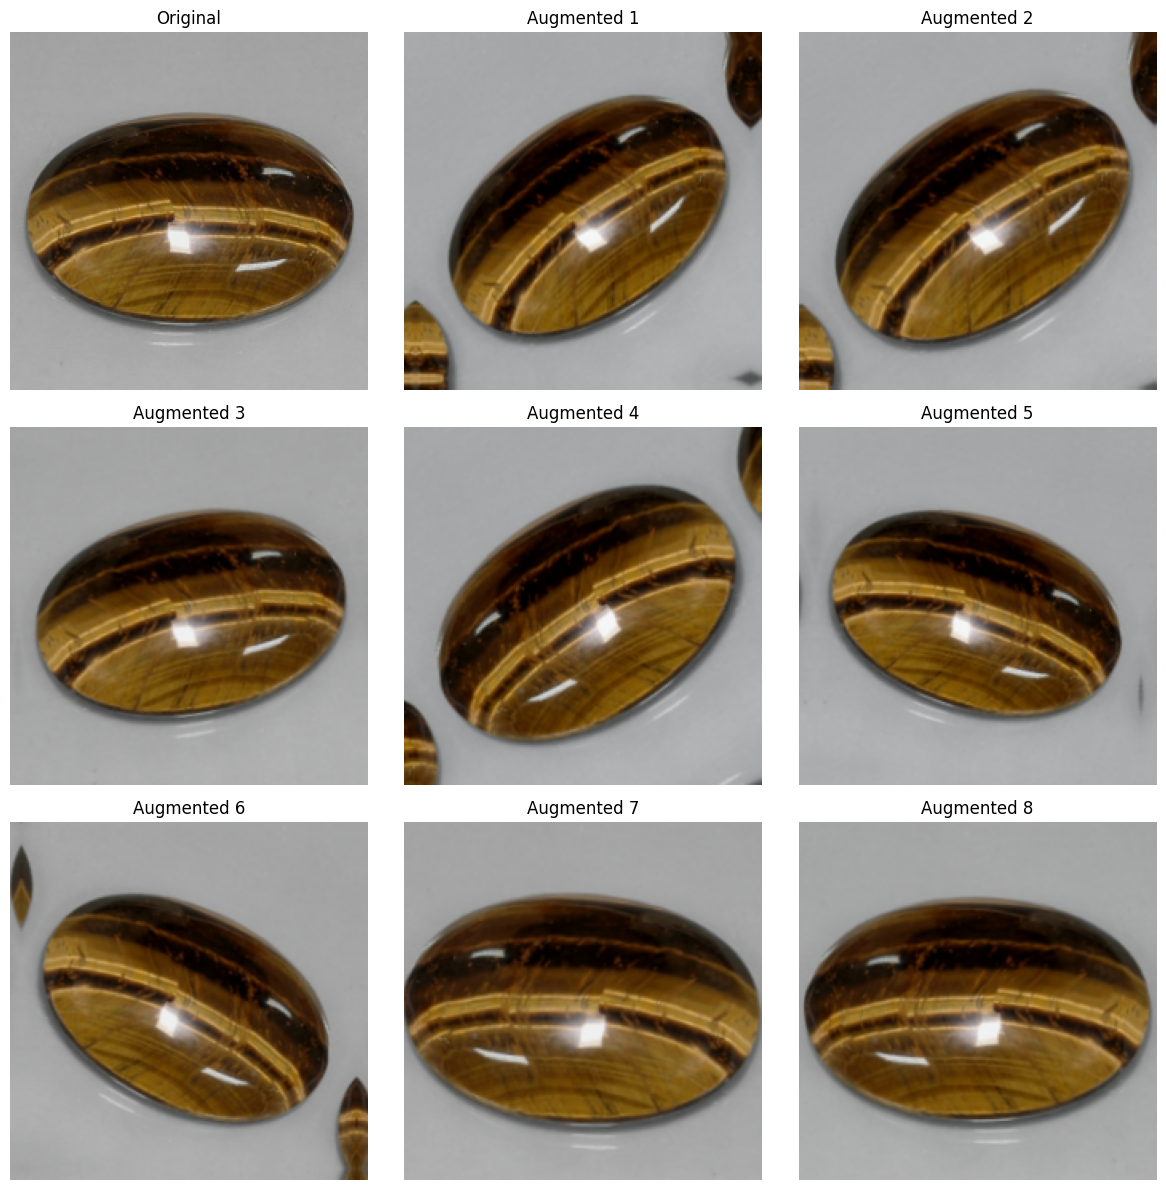

In [9]:
# ==========================================================
# Visualize Data Augmentation
# ==========================================================
#
# Before training the model, it is good practice to
# inspect the augmented images.
#
# This confirms that:
#
# • Images remain realistic.
# • Transformations are not too aggressive.
# • Important gemstone characteristics are preserved.
#
# We display one original gemstone followed by eight
# augmented versions generated in real time.
# ==========================================================

plt.figure(figsize=(12, 12))

for images, labels in train_dataset.take(1):

    # Select the first image from the batch.
    original_image = images[0]

    # Display the original image.
    plt.subplot(3, 3, 1)
    plt.imshow(original_image.numpy().astype("uint8"))
    plt.title("Original")
    plt.axis("off")

    # Display eight augmented versions.
    for i in range(8):

        augmented_image = data_augmentation(
            tf.expand_dims(original_image, axis=0),
            training=True
        )

        plt.subplot(3, 3, i + 2)

        plt.imshow(
            augmented_image[0].numpy().astype("uint8")
        )

        plt.title(f"Augmented {i + 1}")
        plt.axis("off")

plt.tight_layout()

plt.show()

In [10]:
# ==========================================================
# Load the Pre-trained EfficientNetB0 Model
# ==========================================================
#
# Transfer Learning is a deep learning technique where a
# model trained on a large dataset is reused for a new,
# related task.
#
# Instead of training a Convolutional Neural Network (CNN)
# from scratch, we use EfficientNetB0, which has already
# learned millions of visual features from the ImageNet
# dataset.
#
# Advantages of Transfer Learning:
#
# • Faster training
# • Higher accuracy
# • Requires fewer training images
# • Reduces overfitting
#
# Model Configuration:
#
# include_top=False
#     Removes the original ImageNet classification layer.
#
# weights="imagenet"
#     Loads pre-trained ImageNet weights.
#
# input_shape=(224,224,3)
#     Matches the image size used throughout this project.
#
# ==========================================================

base_model = tf.keras.applications.EfficientNetB0(

    include_top=False,

    weights="imagenet",

    input_shape=(224, 224, 3)

)

print("EfficientNetB0 loaded successfully.")

EfficientNetB0 loaded successfully.


In [11]:
# ==========================================================
# Freeze the Feature Extraction Layers
# ==========================================================
#
# EfficientNetB0 has already learned powerful visual
# features from millions of images.
#
# During the first training stage we freeze the entire
# feature extractor so that only the custom classifier
# learns.
#
# This approach:
#
# • Preserves ImageNet knowledge
# • Reduces overfitting
# • Speeds up training
#
# In the second training stage we will unfreeze part of
# EfficientNet and fine-tune the model.
# ==========================================================

base_model.trainable = False

print("Feature extractor frozen.")

Feature extractor frozen.


In [12]:
# ==========================================================
# Build the Gemstone Classification Model
# ==========================================================
#
# Model Architecture
#
# Input Image
#        │
#        ▼
# Data Augmentation
#        │
#        ▼
# EfficientNetB0
#        │
#        ▼
# Global Average Pooling
#        │
#        ▼
# Batch Normalization
#        │
#        ▼
# Dense (256 neurons, ReLU)
#        │
#        ▼
# Dropout (30%)
#        │
#        ▼
# Dense (64 neurons, ReLU)
#        │
#        ▼
# Dropout (20%)
#        │
#        ▼
# Dense (1 neuron, Sigmoid)
#
# Explanation:
#
# GlobalAveragePooling2D
#     Converts feature maps into a feature vector.
#
# BatchNormalization
#     Stabilizes training and accelerates convergence.
#
# Dense Layers
#     Learn task-specific features for gemstone detection.
#
# Dropout
#     Reduces overfitting by randomly disabling neurons
#     during training.
#
# Sigmoid
#     Produces a probability between 0 and 1.
# ==========================================================

inputs = tf.keras.Input(shape=(224, 224, 3), name="Input_Image")

# Apply data augmentation only during training.
x = data_augmentation(inputs)

# Extract deep visual features using EfficientNetB0.
x = base_model(x, training=False)

# Convert feature maps into a one-dimensional feature vector.
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Normalize the extracted features.
x = tf.keras.layers.BatchNormalization()(x)

# First fully connected layer.
x = tf.keras.layers.Dense(
    256,
    activation="relu"
)(x)

# Reduce overfitting.
x = tf.keras.layers.Dropout(0.30)(x)

# Second fully connected layer.
x = tf.keras.layers.Dense(
    64,
    activation="relu"
)(x)

# Additional dropout layer.
x = tf.keras.layers.Dropout(0.20)(x)

# Final prediction layer.
outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid",
    name="Prediction"
)(x)

# Create the complete TensorFlow model.
model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="Gemstone_Detector"
)

print("Model created successfully.")

Model created successfully.


In [13]:
# ==========================================================
# Display Model Summary
# ==========================================================
#
# The model summary provides a detailed overview of the
# network architecture, including:
#
# • Layer names
# • Output shapes
# • Number of trainable parameters
# • Number of non-trainable parameters
#
# This helps verify that the model has been constructed
# correctly before training begins.
# ==========================================================

model.summary()

Model: "Gemstone_Detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Prediction (Dense)              │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,399,140 (16.78 MB)

 Trainable params: 347,009 (1.32 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [14]:
# ==========================================================
# Compile the Model
# ==========================================================
#
# Before training, the model must be compiled.
#
# Compilation defines:
#
# • Optimizer
#     Updates the model weights during training.
#
# • Loss Function
#     Measures prediction error.
#
# • Evaluation Metrics
#     Measures model performance during training.
#
# Since this is a binary classification problem
# (Gemstone vs NotGem), Binary Cross-Entropy is used.
#
# The Adam optimizer is selected because it provides
# adaptive learning rates and generally performs well
# for transfer learning tasks.
# ==========================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[

        tf.keras.metrics.BinaryAccuracy(name="accuracy"),

        tf.keras.metrics.Precision(name="precision"),

        tf.keras.metrics.Recall(name="recall"),

        tf.keras.metrics.AUC(name="auc")

    ]

)

print("Model compiled successfully.")

Model compiled successfully.


In [15]:
# ==========================================================
# Configure Training Callbacks
# ==========================================================
#
# Callbacks allow TensorFlow to automatically perform
# useful actions during model training.
#
# Three callbacks are used:
#
# 1. EarlyStopping
#    Stops training when the validation loss no longer
#    improves. This helps prevent overfitting.
#
# 2. ModelCheckpoint
#    Saves the best-performing model during training.
#    Only the best model is kept for later evaluation
#    and deployment.
#
# 3. ReduceLROnPlateau
#    Reduces the learning rate when validation loss
#    stops improving, allowing the optimizer to make
#    finer weight updates.
# ==========================================================

# Create the models directory if it does not already exist.
MODEL_PATH = Path("../models")
MODEL_PATH.mkdir(exist_ok=True)

callbacks = [

    # Stop training when validation loss no longer improves.
    tf.keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=5,

        restore_best_weights=True,

        verbose=1

    ),

    # Save only the best-performing model.
    tf.keras.callbacks.ModelCheckpoint(

        filepath=MODEL_PATH / "best_gemstone_detector.keras",

        monitor="val_loss",

        save_best_only=True,

        verbose=1

    ),

    # Reduce the learning rate when validation loss plateaus.
    tf.keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.2,

        patience=2,

        min_lr=1e-7,

        verbose=1

    )

]

print("Training callbacks configured successfully.")

Training callbacks configured successfully.


In [16]:
# ==========================================================
# Stage 1 - Feature Extraction
# ==========================================================
#
# In the first training stage, EfficientNetB0 remains
# frozen and only the custom classification layers are
# trained.
#
# This allows the classifier to learn how to interpret
# the visual features extracted by EfficientNet without
# modifying the pre-trained convolutional layers.
#
# The training history is stored for later visualization.
# ==========================================================

INITIAL_EPOCHS = 10

history_stage1 = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=INITIAL_EPOCHS,

    callbacks=callbacks

)

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.8834 - auc: 0.9431 - loss: 0.2656 - precision: 0.9129 - recall: 0.8396
Epoch 1: val_loss improved from None to 0.02961, saving model to ../models/best_gemstone_detector.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 94s 407ms/step - accuracy: 0.9494 - auc: 0.9894 - loss: 0.1352 - precision: 0.9622 - recall: 0.9354 - val_accuracy: 0.9966 - val_auc: 0.9998 - val_loss: 0.0296 - val_precision: 1.0000 - val_recall: 0.9932 - learning_rate: 1.0000e-04
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.9845 - auc: 0.9983 - loss: 0.0460 - precision: 0.9896 - recall: 0.9792
Epoch 2: val_loss improved from 0.02961 to 0.01283, saving model to ../models/best_gemstone_detector.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 150s 678ms/step - accuracy: 0.9855 - auc: 0.9984 - loss: 0.0418 - precision: 0.9883 - recall: 0.9826 - val_accuracy: 0.9977 - val_auc: 0.9999 - val_loss: 0.0128 - val_precision: 1.0000 - val_recall: 0.9954 - learning_rat

In [17]:
# ==========================================================
# Evaluate the Model on the Test Dataset
# ==========================================================
#
# After training, the model is evaluated using the
# independent test dataset.
#
# Unlike the training and validation datasets, the test
# dataset has never been seen by the model.
#
# The evaluation provides an unbiased estimate of how well
# the model is expected to perform on new images uploaded
# by users.
#
# The following metrics are reported:
#
# • Loss
# • Accuracy
# • Precision
# • Recall
# • AUC
# ==========================================================

test_results = model.evaluate(
    test_dataset,
    verbose=1
)

print("\n" + "=" * 50)
print("Test Dataset Performance")
print("=" * 50)

print(f"Test Loss      : {test_results[0]:.4f}")
print(f"Test Accuracy  : {test_results[1]:.4f}")
print(f"Test Precision : {test_results[2]:.4f}")
print(f"Test Recall    : {test_results[3]:.4f}")
print(f"Test AUC       : {test_results[4]:.4f}")

28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 302ms/step - accuracy: 0.9966 - auc: 0.9988 - loss: 0.0150 - precision: 1.0000 - recall: 0.9932

Test Dataset Performance
Test Loss      : 0.0150
Test Accuracy  : 0.9966
Test Precision : 1.0000
Test Recall    : 0.9932
Test AUC       : 0.9988


In [18]:
# ==========================================================
# Generate Predictions on the Test Dataset
# ==========================================================
#
# The trained model predicts the probability that each
# image belongs to the Gemstone class.
#
# Since the output layer uses a Sigmoid activation
# function, each prediction is a probability between
# 0 and 1.
#
# Predictions greater than or equal to 0.50 are classified
# as Gemstone, while predictions below 0.50 are classified
# as NotGem.
# ==========================================================

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())

    y_pred.extend((predictions >= 0.5).astype(int).flatten())

y_true = np.array(y_true)

y_pred = np.array(y_pred)

print("Predictions generated successfully.")

Predictions generated successfully.


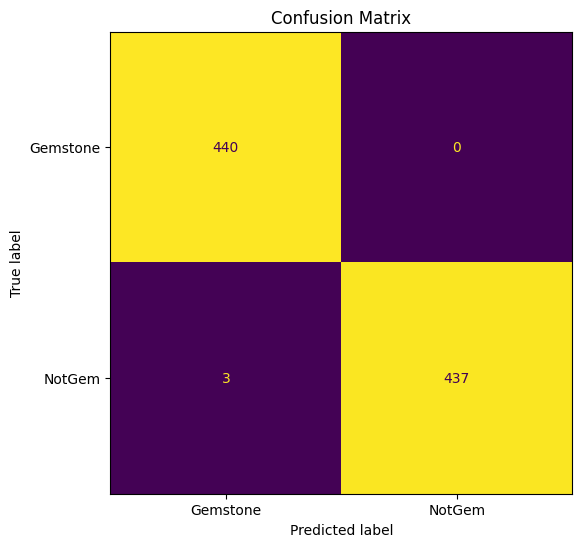

In [19]:
# ==========================================================
# Display the Confusion Matrix
# ==========================================================
#
# A confusion matrix summarizes the classification
# performance by comparing the predicted labels against
# the true labels.
#
# Matrix Layout:
#
#                 Predicted
#
#               Gem  NotGem
#
# Actual Gem      TP     FN
#
# Actual NotGem   FP     TN
#
# The confusion matrix provides insight into the types
# of mistakes made by the model.
# ==========================================================

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names

)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix")

plt.show()

In [20]:
# ==========================================================
# Classification Report
# ==========================================================
#
# The classification report provides detailed performance
# metrics for each class.
#
# Metrics include:
#
# Precision
# Recall
# F1-Score
# Support
#
# These metrics provide a more comprehensive evaluation
# than accuracy alone.
# ==========================================================

from sklearn.metrics import classification_report

print(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names

    )

)

              precision    recall  f1-score   support

    Gemstone       0.99      1.00      1.00       440
      NotGem       1.00      0.99      1.00       440

    accuracy                           1.00       880
   macro avg       1.00      1.00      1.00       880
weighted avg       1.00      1.00      1.00       880



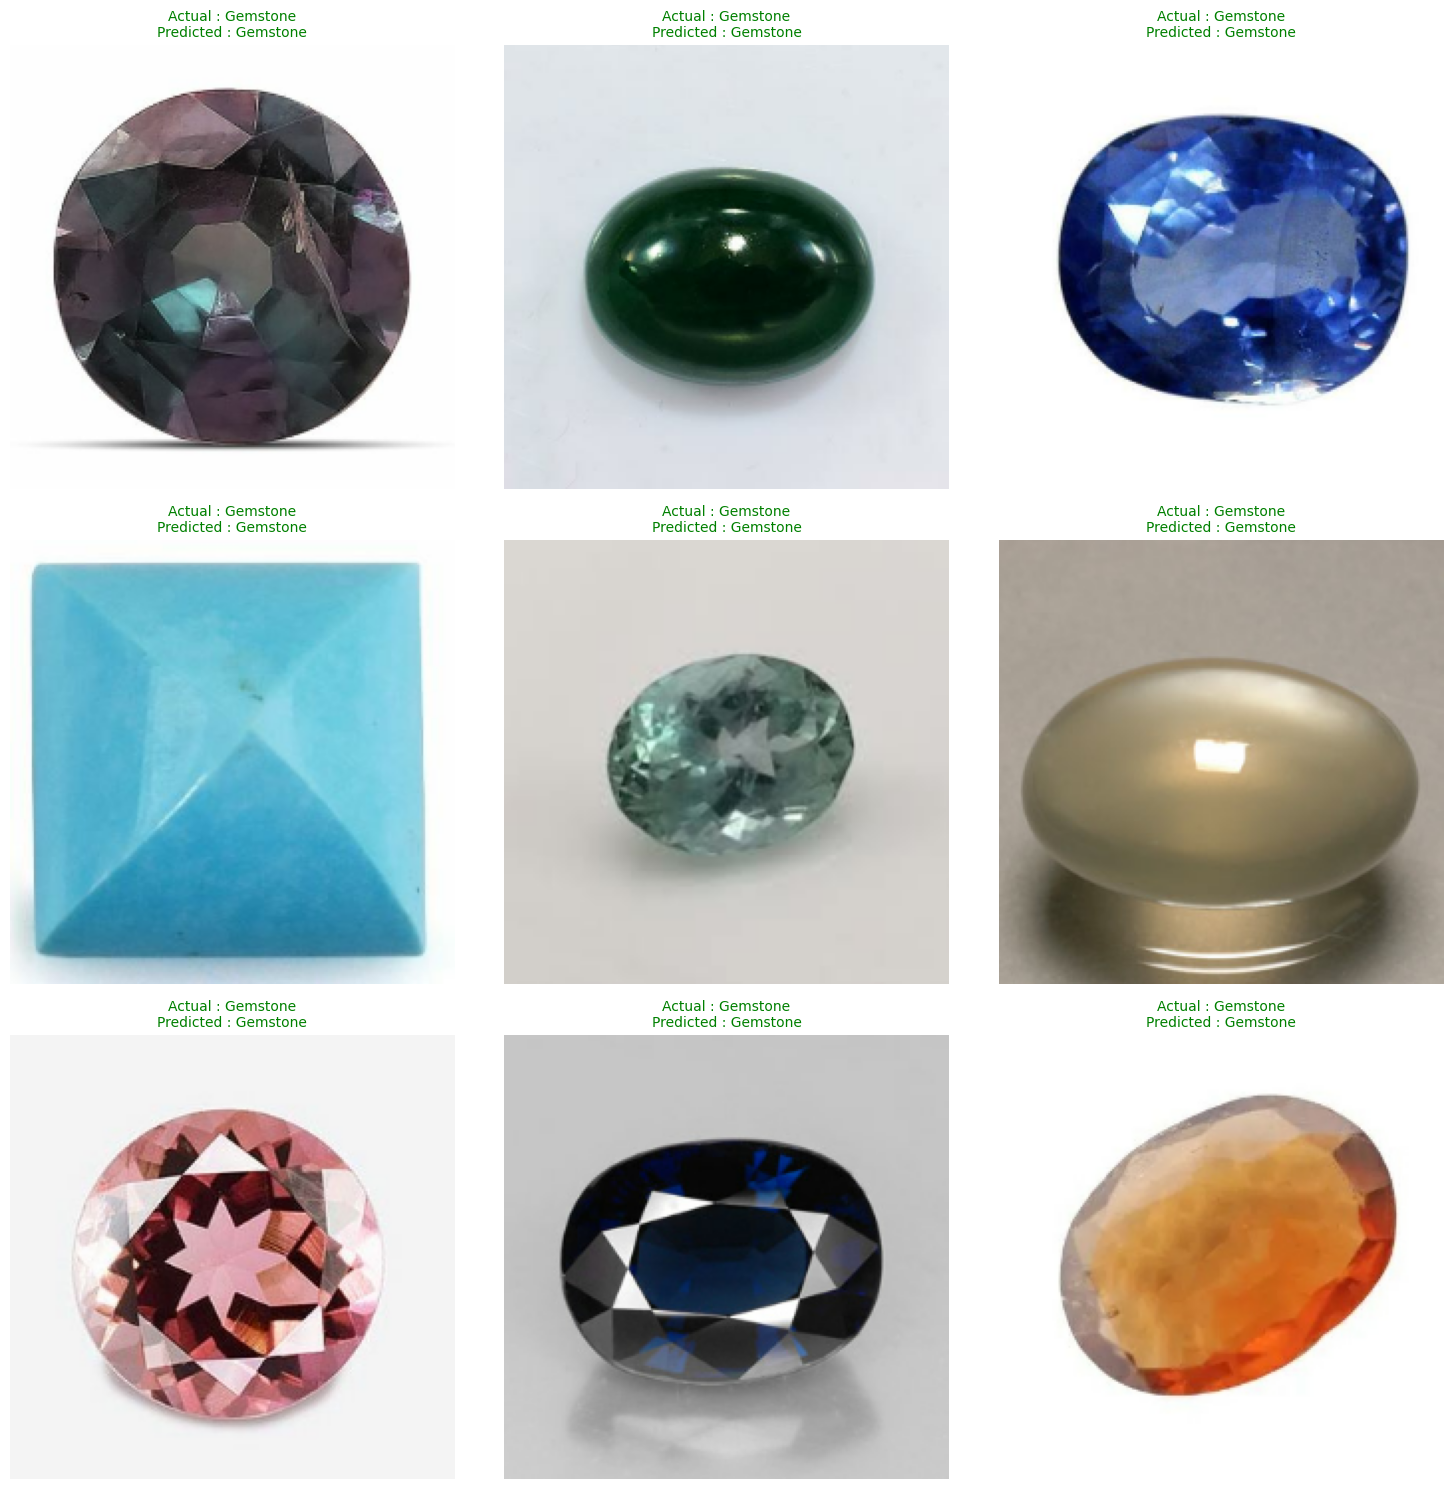

In [21]:
# ==========================================================
# Visualize Sample Predictions
# ==========================================================
#
# Display a selection of test images together with their
# true labels and model predictions.
#
# This provides a qualitative assessment of the model's
# performance and allows visual inspection of correctly
# classified and misclassified images.
# ==========================================================

plt.figure(figsize=(15,15))

for images, labels in test_dataset.take(1):

    predictions = model.predict(images, verbose=0)

    predicted_labels = (predictions >= 0.5).astype(int)

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        actual = class_names[int(labels[i][0])]

        predicted = class_names[int(predicted_labels[i][0])]

        color = "green" if actual == predicted else "red"

        plt.title(
            f"Actual : {actual}\nPredicted : {predicted}",
            color=color,
            fontsize=10
        )

        plt.axis("off")

plt.tight_layout()

plt.show()

In [23]:
# ==========================================================
# Save the Final Model
# ==========================================================
#
# The trained model is saved in Keras format (.keras).
#
# This model will later be loaded by the FastAPI backend
# to classify user-uploaded gemstone images.

# The trained model achieved a test accuracy of 99.66% on the curated evaluation dataset. 
# Real-world performance may vary depending on image quality, lighting conditions, background complexity, and object visibility.

# ==========================================================

model.save("../models/gemstone_detector_final.keras")

print("Model saved successfully.")

Model saved successfully.
